### The three qubit bit flip code

This part is based on Chapter 10.1.1 from "Quantum Computation and Quantum Informaton" by Nielsen and Chuang.

**Encoding**
We will map $| 0 \rangle$ to $| 000 \rangle$ and  $| 1 \rangle$ to $| 111 \rangle$, which can be done using 2 CNOT gates.

This way, $\alpha | 0 \rangle + \beta | 1 \rangle$ is encoded as $\alpha | 000 \rangle + \beta | 111 \rangle$.

**Decoding**
Assume that not more than one bit flips occured. Then there are 4 options:

1. No bit flip occured. State after transmission $\alpha | 000 \rangle + \beta | 111 \rangle$.
2. First bit flipped. State after transmission $\alpha | 100 \rangle + \beta | 011 \rangle$.
3. Second bit flipped. State after transmission $\alpha | 010 \rangle + \beta | 101 \rangle$.
4. Third bit flipped. State after transmission $\alpha | 001 \rangle + \beta | 110 \rangle$.

Book suggests to do a measurement to do a measurement which distingusishes these 4 states and does not changes state. Indeed, these 4 cases correspond to 4 orthonal subspaces, and we could take projectors on these subspaces as measurement opertors.

However, how to implement such measurement. One way to implement measurement not in computational basis is to apply unitary transform, after which measurement in computational basis will give desired result. For example, if we want to meaure in basis $|+ \rangle, |- \rangle$, we could apply Hadamard gate and measure in $|0 \rangle, |1 \rangle$ basis.

Let's explicitly design such transformation, by saying where should it take one of 4 possible outcomes:

$\alpha | 000 \rangle + \beta | 111 \rangle \to (\alpha |0 \rangle + \beta |1 \rangle) | 00 \rangle$

$\alpha | 100 \rangle + \beta | 011 \rangle \to (\alpha |0 \rangle + \beta |1 \rangle) | 11 \rangle$

$\alpha | 010 \rangle + \beta | 101 \rangle \to (\alpha |0 \rangle + \beta |1 \rangle) | 10 \rangle$

$\alpha | 001 \rangle + \beta | 110 \rangle \to (\alpha |0 \rangle + \beta |1 \rangle) | 01 \rangle$

Now by doing measurement in computational basis for two rightmost qubits we obtain result of measurement which we initially wanted, and measurement wouldn't change the state.

Then we could apply inverse transformation and use mesurement result to decide which bit was flipped (if any), and flip it.

But we don't need to do all this, as after this transformation we see that regarless of which bit was flipped, leftmost qubit is already equal to qubit we want to restore. So, we just need to apply transformation, and we don't need to do any measurements.

So, how do we build this transformation? It is, in fact, a permutation:

$\alpha | 000 \rangle \to | 000 \rangle$

$\alpha | 001 \rangle \to | 001 \rangle$

$\alpha | 010 \rangle \to | 010 \rangle$

$\alpha | 011 \rangle \to | 111 \rangle$

$\alpha | 100 \rangle \to | 011 \rangle$

$\alpha | 101 \rangle \to | 110 \rangle$

$\alpha | 110 \rangle \to | 101 \rangle$

$\alpha | 111 \rangle \to | 100 \rangle$

All is left is to represent it as matrix and decompose it into X and CCNOT gates: 

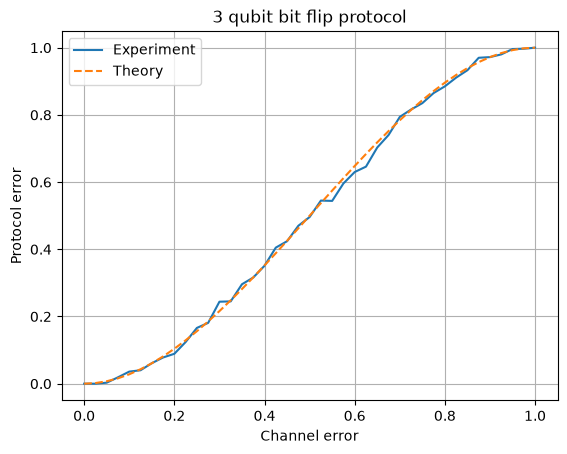

Time: 65.71s


In [1]:
from error_correction.channels import BitFlipChannel
from error_correction.protocols import ThreeQubitBitFlipProtocol
from error_correction.utils import test_protocol_once, plot_errors

plot_errors(ThreeQubitBitFlipProtocol(), 
            num_experiments=1000, 
            num_points=41, 
            theoretical=lambda x:3*x**2*(1-x)+x**3)

In [2]:
data = {}
test_protocol_once(ThreeQubitBitFlipProtocol(), BitFlipChannel(0.3), output=data)
print(data['circuit'])

aux_1: ─────────────────────────────X───X───────@───X───X───@───────@───────@───────@───X───@───X───X───@───M───
                                    │           │       │   │       │       │       │       │       │   │
aux_2: ─────────────────────────────┼───X───X───@───────@───@───────X───X───@───X───X───────@───────@───@───────
                                    │   │       │       │   │       │       │       │       │       │   │
q_init: ───Ry(0.354π)───Rz(0.72π)───@───@───X───X───────@───X───X───@───X───X───X───@───X───X───────@───X───M───
